# Experiment 4: Transfer Learning Using Pre-Trained Vision Models for Image Recognition

## Task A: Dataset Preparation

In [5]:
print("24BAD049 - JESSICA SAM B")
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tongpython/cat-and-dog
!unzip -q cat-and-dog.zip -d cat_and_dog

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_full_ds = tf.keras.utils.image_dataset_from_directory(
    'cat_and_dog/training_set/training_set',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

class_names = train_full_ds.class_names

test_full_ds = tf.keras.utils.image_dataset_from_directory(
    'cat_and_dog/test_set/test_set',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_batches = tf.data.experimental.cardinality(train_full_ds).numpy()
val_size = int(0.2 * train_batches)

val_ds = train_full_ds.take(val_size)
train_ds = train_full_ds.skip(val_size)
test_ds = test_full_ds

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print(class_names)
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

24BAD049 - JESSICA SAM B


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
cat-and-dog.zip: Skipping, found more recently modified local copy (use --force to force download)
replace cat_and_dog/test_set/test_set/cats/_DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace cat_and_dog/test_set/test_set/cats/cat.4001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
['cats', 'dogs']
Train batches: 201
Validation batches: 50
Test batches: 64


## Task B: Implementing Transfer Learning

In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Task C: Model Training and Performance Evaluation

Epoch 1/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 53s 184ms/step - accuracy: 0.5945 - loss: 0.6682 - val_accuracy: 0.6325 - val_loss: 0.6435
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 55s 96ms/step - accuracy: 0.5986 - loss: 0.6645 - val_accuracy: 0.6225 - val_loss: 0.6435
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 107ms/step - accuracy: 0.6151 - loss: 0.6546 - val_accuracy: 0.6431 - val_loss: 0.6369
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.6230 - loss: 0.6474 - val_accuracy: 0.6431 - val_loss: 0.6348
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.6297 - loss: 0.6426 - val_accuracy: 0.6481 - val_loss: 0.6322
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.6329 - loss: 0.6396 - val_accuracy: 0.6488 - val_loss: 0.6300
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.6368 - loss: 0.6362 - val_accuracy: 0.6450 - val_loss: 0.6278
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - accuracy: 0.6400 - loss: 0.

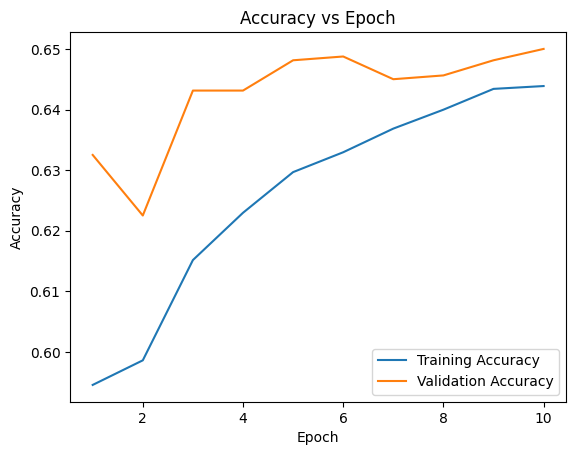

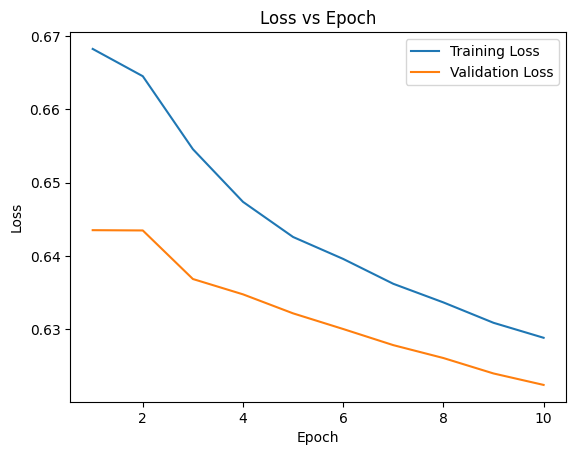

In [3]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

test_loss, test_accuracy = model.evaluate(test_ds)

print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])
print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])
print("Test Accuracy:", test_accuracy)

import matplotlib.pyplot as plt

epochs_range = range(1, len(history.history['accuracy']) + 1)

plt.figure()
plt.plot(epochs_range, history.history['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, history.history['loss'], label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.show()

## Task D: Using Hugging Face Pre-Trained Models

In [4]:
!pip install -q transformers

from transformers import pipeline
from PIL import Image
import numpy as np

hf_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

sample_images, sample_labels = next(iter(test_ds))

for i in range(5):
    image_array = (sample_images[i].numpy() * 255).astype(np.uint8)
    pil_image = Image.fromarray(image_array)

    hf_result = hf_classifier(pil_image)
    hf_label = hf_result[0]['label']

    tl_pred = model.predict(np.expand_dims(sample_images[i].numpy(), axis=0))
    tl_label = class_names[int(tl_pred[0][0] > 0.5)]

    actual_label = class_names[int(sample_labels[i].numpy())]

    print("Actual Label:", actual_label)
    print("Transfer Learning Model Prediction:", tl_label)
    print("Hugging Face Model Prediction:", hf_label)
    print("-" * 40)

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Actual Label: cats
Transfer Learning Model Prediction: dogs
Hugging Face Model Prediction: tiger cat
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Actual Label: cats
Transfer Learning Model Prediction: cats
Hugging Face Model Prediction: Egyptian cat
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Actual Label: cats
Transfer Learning Model Prediction: cats
Hugging Face Model Prediction: tiger cat
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Actual Label: cats
Transfer Learning Model Prediction: cats
Hugging Face Model Prediction: space heater
----------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Actual Label: cats
Transfer Learning Model Prediction: dogs
Hugging Face Model Prediction: tabby, tabby cat
----------------------------------------
